# Cell 1 — Mount Drive & Tạo cấu trúc thư mục

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

BASE      = '/content/drive/MyDrive/Cuoi_ki_AI'
DATASET   = f'{BASE}/dataset'
RAW_PATH  = f'{BASE}/dataset_raw'
SC_RAW    = f'{BASE}/speech_commands_raw'
MODEL_DIR = f'{BASE}/models'
LOG_DIR   = f'{BASE}/logs'

for d in [DATASET, SC_RAW, MODEL_DIR, LOG_DIR]:
    os.makedirs(d, exist_ok=True)

LABELS   = ['go', 'play', 'replay', 'next', 'back', 'stop']
SR       = 22050
DURATION = 1.5

print("✅ Cấu trúc thư mục Drive:")
for d in [DATASET, SC_RAW, MODEL_DIR, LOG_DIR]:
    print(f"   {d}")

Mounted at /content/drive
✅ Cấu trúc thư mục Drive:
   /content/drive/MyDrive/Cuoi_ki_AI/dataset
   /content/drive/MyDrive/Cuoi_ki_AI/speech_commands_raw
   /content/drive/MyDrive/Cuoi_ki_AI/models
   /content/drive/MyDrive/Cuoi_ki_AI/logs


# Cell 2 — Cài thư viện

In [2]:
!pip install -q librosa==0.10.2 audiomentations soundfile scikit-learn \
    numpy scipy matplotlib seaborn joblib gtts tqdm
print("✅ Cài xong")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.0/260.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 12.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
typer 0.24.1 requires click>=8.2.1, but you have click 8.1.8 which is incompatible.
✅ Cài xong


# Cell 3 — Chuyển đổi data gốc (m4a → wav)

In [3]:
import librosa, soundfile as sf, zipfile, os
from pathlib import Path

zip_path = f'{BASE}/sound_recordings.zip'
if os.path.exists(zip_path):
    print("📦 Giải nén sound_recordings.zip...")
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(RAW_PATH)
    print("✅ Xong")
else:
    print(f"⚠️  Không thấy zip, dùng data đã giải nén tại: {RAW_PATH}")

print("\n🔄 Chuyển đổi m4a → wav...\n")
for label in LABELS:
    src_folder = None
    for root, dirs, files in os.walk(RAW_PATH):
        if os.path.basename(root).lower() == label.lower():
            src_folder = root
            break
    if src_folder is None:
        print(f"  ⚠️  Không tìm thấy folder '{label}'")
        continue

    out_folder = os.path.join(DATASET, label)
    os.makedirs(out_folder, exist_ok=True)

    audio_files = [f for f in os.listdir(src_folder)
                   if f.lower().endswith(('.m4a','.wav','.mp3','.ogg','.flac'))]
    ok = skip = 0
    for fname in audio_files:
        dst = os.path.join(out_folder, Path(fname).stem + '.wav')
        if os.path.exists(dst):
            skip += 1; continue
        try:
            y, _ = librosa.load(os.path.join(src_folder, fname), sr=SR, mono=True)
            sf.write(dst, y, SR)
            ok += 1
        except Exception as e:
            print(f"    ✗ {fname}: {e}")

    total = len([f for f in os.listdir(out_folder) if f.endswith('.wav')])
    print(f"  [{label:6s}] convert={ok}  skip={skip}  tổng={total}")

print("\n✅ Data gốc sẵn sàng")

📦 Giải nén sound_recordings.zip...
✅ Xong

🔄 Chuyển đổi m4a → wav...



/tmp/ipykernel_5721/2065875697.py:35: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(os.path.join(src_folder, fname), sr=SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_5721/2065875697.py:35: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(os.path.join(src_folder, fname), sr=SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_5721/2065875697.py:35: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(os.

  [go    ] convert=144  skip=0  tổng=144


/tmp/ipykernel_5721/2065875697.py:35: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(os.path.join(src_folder, fname), sr=SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_5721/2065875697.py:35: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(os.path.join(src_folder, fname), sr=SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_5721/2065875697.py:35: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(os.

  [play  ] convert=144  skip=0  tổng=144


...

  [next  ] convert=144  skip=0  tổng=144


/tmp/ipykernel_5721/2065875697.py:35: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(os.path.join(src_folder, fname), sr=SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_5721/2065875697.py:35: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(os.path.join(src_folder, fname), sr=SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_5721/2065875697.py:35: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(os.

  [back  ] convert=144  skip=0  tổng=144


/tmp/ipykernel_5721/2065875697.py:35: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(os.path.join(src_folder, fname), sr=SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_5721/2065875697.py:35: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(os.path.join(src_folder, fname), sr=SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_5721/2065875697.py:35: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(os.

  [stop  ] convert=144  skip=0  tổng=144

✅ Data gốc sẵn sàng


# Cell 4 — Tải Google Speech Commands v2 về Drive (chỉ chạy 1 lần)

In [4]:
import tarfile, urllib.request, os

SC_TAR = f'{BASE}/speech_commands_v0.02.tar.gz'
SC_URL = 'http://download.tensorflow.org/data/speech_commands_v0.02.tar.gz'

if not os.path.exists(SC_TAR):
    print("⬇️  Download Google SC v2 (~2.3GB)...")
    def progress(block, block_size, total):
        done = block * block_size
        if total > 0 and block % 500 == 0:
            print(f"   {min(done*100/total,100):.1f}%  "
                  f"({done//1024//1024}MB / {total//1024//1024}MB)", end='\r')
    urllib.request.urlretrieve(SC_URL, SC_TAR, reporthook=progress)
    print(f"\n✅ Download xong → {SC_TAR}")
else:
    print(f"✅ File đã có: {SC_TAR}")

if not os.path.exists(os.path.join(SC_RAW, 'go')):
    print("📦 Giải nén (~5–10 phút)...")
    with tarfile.open(SC_TAR, 'r:gz') as tar:
        tar.extractall(SC_RAW)
    print(f"✅ Giải nén xong → {SC_RAW}")
else:
    print(f"✅ Đã giải nén: {SC_RAW}")

for w in ['go', 'stop', 'play']:
    folder = os.path.join(SC_RAW, w)
    if os.path.exists(folder):
        n = len([f for f in os.listdir(folder) if f.endswith('.wav')])
        print(f"   [{w}] {n} file trong Google SC")

⬇️  Download Google SC v2 (~2.3GB)...
   100.0%  (2316MB / 2316MB)
✅ Download xong → /content/drive/MyDrive/Cuoi_ki_AI/speech_commands_v0.02.tar.gz
📦 Giải nén (~5–10 phút)...


/tmp/ipykernel_5721/129252259.py:21: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(SC_RAW)


✅ Giải nén xong → /content/drive/MyDrive/Cuoi_ki_AI/speech_commands_raw
   [go] 3880 file trong Google SC
   [stop] 3872 file trong Google SC


# Cell 5 — Merge Google SC v2 (CHỈ 200 mẫu/lớp)

In [5]:
import random, librosa, soundfile as sf, os
import numpy as np

# ── Sửa lại: chỉ go và stop có trong Google SC v2 ──
MAX_SC_PER_CLASS = 200
MATCHED_WORDS    = ['go', 'stop']   # Bỏ 'play' vì không có trong Google SC v2

random.seed(42)
print(f"🔄 Merge Google SC v2 — tối đa {MAX_SC_PER_CLASS} mẫu/lớp")
print(f"   Chỉ merge: {MATCHED_WORDS}  (play không có trong Google SC v2)\n")

for word in MATCHED_WORDS:
    src_folder = os.path.join(SC_RAW, word)
    dst_folder = os.path.join(DATASET, word)
    os.makedirs(dst_folder, exist_ok=True)

    existing_gsc = [f for f in os.listdir(dst_folder) if f.startswith('gsc_')]
    if len(existing_gsc) >= MAX_SC_PER_CLASS:
        print(f"  [{word}] Đã có {len(existing_gsc)} gsc_ samples — bỏ qua")
        continue

    mine     = len([f for f in os.listdir(dst_folder) if not f.startswith(('gsc_','tts_'))])
    sc_files = [f for f in os.listdir(src_folder) if f.endswith('.wav')]
    selected = random.sample(sc_files, min(MAX_SC_PER_CLASS, len(sc_files)))

    ok = 0
    for i, fname in enumerate(selected):
        dst_path = os.path.join(dst_folder, f'gsc_{word}_{i:04d}.wav')
        if os.path.exists(dst_path):
            ok += 1; continue
        try:
            y, _ = librosa.load(os.path.join(src_folder, fname),
                                 sr=SR, mono=True, duration=DURATION)
            sf.write(dst_path, y, SR)
            ok += 1
        except:
            pass

    total = len([f for f in os.listdir(dst_folder) if f.endswith('.wav')])
    print(f"  [{word:6s}] mine={mine}  +gsc={ok}  tổng={total}")

# Thông báo play dùng TTS thay thế
print(f"\n  [play  ] Không có trong Google SC v2")
print(f"           → Sẽ dùng TTS synthesis ở Cell 6 (cùng với next/back/replay)")
print(f"\n✅ Merge Google SC hoàn tất")

🔄 Merge Google SC v2 — tối đa 200 mẫu/lớp
   Chỉ merge: ['go', 'stop']  (play không có trong Google SC v2)

  [go    ] mine=144  +gsc=200  tổng=344
  [stop  ] mine=144  +gsc=200  tổng=344

  [play  ] Không có trong Google SC v2
           → Sẽ dùng TTS synthesis ở Cell 6 (cùng với next/back/replay)

✅ Merge Google SC hoàn tất


# Cell 6 — TTS synthesis cho replay, next, back, play


In [6]:
from gtts import gTTS
import librosa, soundfile as sf, numpy as np, os

# Thêm 'play' vào đây vì không có trong Google SC v2
SYNTH_WORDS = ['play', 'next', 'back', 'replay']
ACCENTS     = ['com', 'co.uk', 'com.au', 'co.in', 'ca']

print("🗣️  TTS synthesis cho: play, next, back, replay\n")
print("   play  — không có trong Google SC v2, dùng TTS thay thế")
print("   next, back, replay — không có trong bất kỳ dataset nào\n")

for word in SYNTH_WORDS:
    out_folder = os.path.join(DATASET, word)
    os.makedirs(out_folder, exist_ok=True)

    tts_exist = [f for f in os.listdir(out_folder) if f.startswith('tts_')]
    if len(tts_exist) >= 40:
        total = len([f for f in os.listdir(out_folder) if f.endswith('.wav')])
        print(f"  [{word}] Đã có {len(tts_exist)} TTS samples — bỏ qua (tổng={total})")
        continue

    existing = len([f for f in os.listdir(out_folder) if f.endswith('.wav')])
    idx = existing
    added = 0

    for accent in ACCENTS:
        for slow in [False, True]:
            try:
                tts = gTTS(text=word, lang='en', tld=accent, slow=slow)
                tmp = f'/tmp/tts_{word}_{accent}_{slow}.mp3'
                tts.save(tmp)
                y, _ = librosa.load(tmp, sr=SR)

                variants = [
                    y,
                    librosa.effects.pitch_shift(y, sr=SR, n_steps=2.0),
                    librosa.effects.pitch_shift(y, sr=SR, n_steps=-2.0),
                    librosa.effects.pitch_shift(y, sr=SR, n_steps=3.5),
                    librosa.effects.time_stretch(y, rate=0.85),
                    librosa.effects.time_stretch(y, rate=1.15),
                ]

                for v in variants:
                    target = int(SR * DURATION)
                    v = np.pad(v, (0, max(0, target - len(v))))[:target]
                    sf.write(os.path.join(out_folder, f'tts_{word}_{idx:04d}.wav'), v, SR)
                    idx += 1; added += 1

                os.remove(tmp)
            except Exception as e:
                print(f"    ⚠ {accent}/{slow}: {e}")

    total = len([f for f in os.listdir(out_folder) if f.endswith('.wav')])
    print(f"  [{word:6s}] +{added} TTS samples → tổng={total}")

print("\n✅ TTS synthesis hoàn tất")

🗣️  TTS synthesis cho: play, next, back, replay

   play  — không có trong Google SC v2, dùng TTS thay thế
   next, back, replay — không có trong bất kỳ dataset nào

  [play  ] +60 TTS samples → tổng=204
  [next  ] +60 TTS samples → tổng=204
  [back  ] +60 TTS samples → tổng=204
  [replay] +60 TTS samples → tổng=204

✅ TTS synthesis hoàn tất


# Cell 7 — Kiểm tra phân phối & cân bằng

📊 Phân phối dataset cuối cùng:

  Label       Mine     GSC     TTS    Total
  ----------------------------------------
  go           144     200       0      344  ██████████████████████
  play         144       0      60      204  █████████████
  replay       144       0      60      204  █████████████
  next         144       0      60      204  █████████████
  back         144       0      60      204  █████████████
  stop         144     200       0      344  ██████████████████████


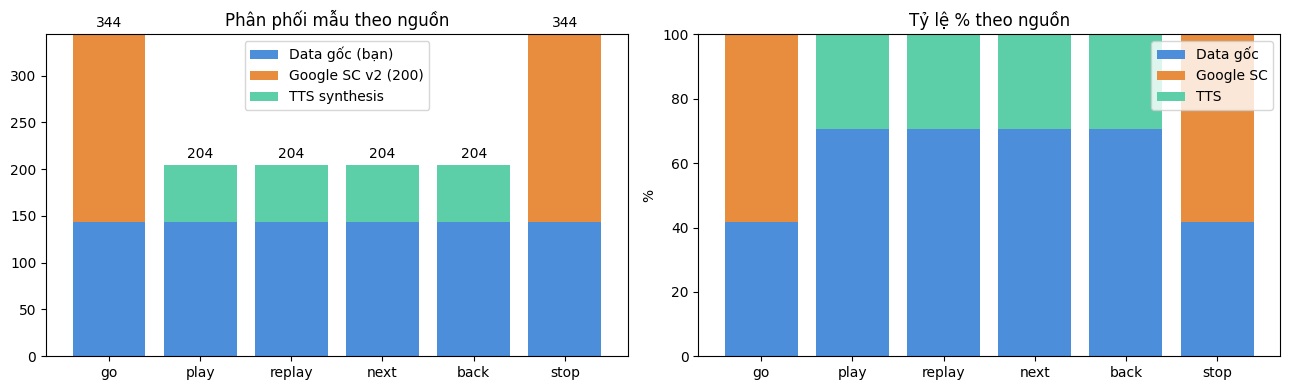


  Max=344  Min=204  Tỷ lệ=1.7x
  ✅ Dataset cân bằng đủ tốt — không cần down-sample


In [7]:
import matplotlib.pyplot as plt, os, random

print("📊 Phân phối dataset cuối cùng:\n")
print(f"  {'Label':<8}  {'Mine':>6}  {'GSC':>6}  {'TTS':>6}  {'Total':>7}")
print(f"  {'-'*40}")

counts = {}
for label in LABELS:
    folder = os.path.join(DATASET, label)
    files  = [f for f in os.listdir(folder) if f.endswith('.wav')]
    mine   = len([f for f in files if not f.startswith(('gsc_','tts_'))])
    gsc    = len([f for f in files if f.startswith('gsc_')])
    tts    = len([f for f in files if f.startswith('tts_')])
    counts[label] = len(files)
    bar    = '█' * (len(files) // 15)
    print(f"  {label:<8}  {mine:>6}  {gsc:>6}  {tts:>6}  {len(files):>7}  {bar}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Stacked bar
mine_c = []
gsc_c  = []
tts_c  = []
for label in LABELS:
    folder = os.path.join(DATASET, label)
    files  = [f for f in os.listdir(folder) if f.endswith('.wav')]
    mine_c.append(len([f for f in files if not f.startswith(('gsc_','tts_'))]))
    gsc_c.append(len([f for f in files if f.startswith('gsc_')]))
    tts_c.append(len([f for f in files if f.startswith('tts_')]))

x = range(len(LABELS))
axes[0].bar(LABELS, mine_c, label='Data gốc (bạn)', color='#4c8eda')
axes[0].bar(LABELS, gsc_c,  bottom=mine_c, label='Google SC v2 (200)', color='#e88c3d')
axes[0].bar(LABELS, tts_c,  bottom=[m+g for m,g in zip(mine_c,gsc_c)],
            label='TTS synthesis', color='#5ccea8')
axes[0].set_title('Phân phối mẫu theo nguồn')
axes[0].legend()
axes[0].bar_label(axes[0].containers[-1],
                  labels=[str(counts[l]) for l in LABELS], padding=3)

# Tỷ lệ
ratios = [[mine_c[i]/counts[LABELS[i]]*100,
           gsc_c[i]/counts[LABELS[i]]*100,
           tts_c[i]/counts[LABELS[i]]*100] for i in range(len(LABELS))]
axes[1].bar(LABELS, [r[0] for r in ratios], label='Data gốc', color='#4c8eda')
axes[1].bar(LABELS, [r[1] for r in ratios],
            bottom=[r[0] for r in ratios], label='Google SC', color='#e88c3d')
axes[1].bar(LABELS, [r[2] for r in ratios],
            bottom=[r[0]+r[1] for r in ratios], label='TTS', color='#5ccea8')
axes[1].set_title('Tỷ lệ % theo nguồn')
axes[1].set_ylabel('%')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{LOG_DIR}/dataset_distribution.png', dpi=150)
plt.show()

# Cân bằng nếu lệch > 4x
max_c = max(counts.values())
min_c = min(counts.values())
print(f"\n  Max={max_c}  Min={min_c}  Tỷ lệ={max_c/min_c:.1f}x")

if max_c / min_c > 4:
    KEEP = min_c + 200
    print(f"\n  ⚠️  Mất cân bằng — down-sample về {KEEP} mẫu/lớp")
    for label in LABELS:
        folder = os.path.join(DATASET, label)
        files  = [f for f in os.listdir(folder) if f.endswith('.wav')]
        if len(files) > KEEP:
            # Ưu tiên xóa gsc_ và tts_ trước, giữ data gốc
            removable = [f for f in files if f.startswith(('gsc_','tts_'))]
            n_remove  = len(files) - KEEP
            to_remove = random.sample(removable, min(n_remove, len(removable)))
            for f in to_remove:
                os.remove(os.path.join(folder, f))
            new_total = len([f for f in os.listdir(folder) if f.endswith('.wav')])
            print(f"    [{label}] {len(files)} → {new_total}")
else:
    print("  ✅ Dataset cân bằng đủ tốt — không cần down-sample")

# Cell 8 — Hàm trích xuất đặc trưng

In [8]:
import numpy as np, librosa
from scipy.stats import skew, kurtosis

N_MFCC = 20; HOP_LENGTH = 512; N_FFT = 2048

def extract_features(y, sr=SR):
    target_len = int(sr * DURATION)
    y = np.pad(y, (0, max(0, target_len-len(y))))[:target_len]
    y = np.append(y[0], y[1:] - 0.97*y[:-1])
    features = []

    mfcc  = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH)
    mfcc1 = librosa.feature.delta(mfcc)
    mfcc2 = librosa.feature.delta(mfcc, order=2)
    for m in [mfcc, mfcc1, mfcc2]:
        features.extend(np.mean(m, axis=1)); features.extend(np.std(m, axis=1))

    for feat in [
        librosa.feature.spectral_centroid(y=y, sr=sr, hop_length=HOP_LENGTH)[0],
        librosa.feature.spectral_rolloff(y=y, sr=sr, hop_length=HOP_LENGTH)[0],
        librosa.feature.spectral_bandwidth(y=y, sr=sr, hop_length=HOP_LENGTH)[0],
        librosa.feature.spectral_flatness(y=y, hop_length=HOP_LENGTH)[0],
    ]:
        features.extend([np.mean(feat), np.std(feat), skew(feat), kurtosis(feat)])
    features.extend(np.mean(librosa.feature.spectral_contrast(y=y, sr=sr, hop_length=HOP_LENGTH), axis=1))

    chroma = librosa.feature.chroma_stft(y=y, sr=sr, hop_length=HOP_LENGTH)
    features.extend(np.mean(chroma, axis=1)); features.extend(np.std(chroma, axis=1))

    for feat in [
        librosa.feature.zero_crossing_rate(y, hop_length=HOP_LENGTH)[0],
        librosa.feature.rms(y=y, hop_length=HOP_LENGTH)[0],
    ]:
        features.extend([np.mean(feat), np.std(feat), np.max(feat), skew(feat)])

    mel    = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=32, hop_length=HOP_LENGTH)
    mel_db = librosa.power_to_db(mel)
    features.extend(np.mean(mel_db, axis=1)); features.extend(np.std(mel_db, axis=1))

    mel_norm = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)
    img = (mel_norm * 255).astype(np.uint8)
    def raw_m(img, p, q):
        xv, yv = np.meshgrid(np.arange(img.shape[1]), np.arange(img.shape[0]))
        return np.sum((xv**p)*(yv**q)*img)
    m00 = raw_m(img,0,0)+1e-10; cx = raw_m(img,1,0)/m00; cy = raw_m(img,0,1)/m00
    def cm_(img, p, q):
        xv, yv = np.meshgrid(np.arange(img.shape[1])-cx, np.arange(img.shape[0])-cy)
        return np.sum((xv**p)*(yv**q)*img)
    mu20,mu02,mu11 = cm_(img,2,0)/(m00**2),cm_(img,0,2)/(m00**2),cm_(img,1,1)/(m00**2)
    mu30,mu03      = cm_(img,3,0)/(m00**2.5),cm_(img,0,3)/(m00**2.5)
    mu21,mu12      = cm_(img,2,1)/(m00**2.5),cm_(img,1,2)/(m00**2.5)
    features.extend([mu20+mu02, (mu20-mu02)**2+4*mu11**2,
                     (mu30-3*mu12)**2+(3*mu21-mu03)**2, (mu30+mu12)**2+(mu21+mu03)**2])

    f0, vf, _ = librosa.pyin(y, fmin=80, fmax=400, sr=sr)
    f0v = f0[vf] if vf is not None and vf.any() else np.array([0.0])
    features.extend([float(np.mean(f0v)), float(np.std(f0v)),
                     float(np.mean(vf.astype(float))) if vf is not None else 0.0,
                     float(len(f0v)/max(len(f0) if f0 is not None else 1, 1))])
    features.append(float(np.sum(np.abs(y) > 0.01)/len(y)))
    return np.array(features, dtype=np.float32)

# Test
import os
f0 = os.listdir(f'{DATASET}/go')[0]
yt, _ = librosa.load(f'{DATASET}/go/{f0}', sr=SR)
print(f"✅ Feature vector: {extract_features(yt).shape[0]} chiều")

✅ Feature vector: 248 chiều


# Cell 9 — Augmentation

In [9]:
from audiomentations import Compose, AddGaussianNoise, TimeStretch, PitchShift, Shift, Gain
import numpy as np

AUG_PER_SAMPLE = 4

augmenter = Compose([
    AddGaussianNoise(min_amplitude=0.003, max_amplitude=0.015, p=0.6),
    TimeStretch(min_rate=0.85, max_rate=1.15, p=0.5),
    PitchShift(min_semitones=-2.0, max_semitones=2.0, p=0.5),
    Shift(min_shift=-0.15, max_shift=0.15, p=0.4),
    Gain(min_gain_db=-3, max_gain_db=3, p=0.4),
])

def augment_audio(y, sr, n=AUG_PER_SAMPLE):
    return [augmenter(samples=y.astype(np.float32), sample_rate=sr) for _ in range(n)]

print(f"✅ Augmenter sẵn sàng")
print(f"   Data gốc bạn (mine_)  : augment ×{AUG_PER_SAMPLE}")
print(f"   Google SC (gsc_)      : KHÔNG augment (đã đủ đa dạng)")
print(f"   TTS synthesis (tts_)  : KHÔNG augment (đã tạo nhiều biến thể)")

✅ Augmenter sẵn sàng
   Data gốc bạn (mine_)  : augment ×4
   Google SC (gsc_)      : KHÔNG augment (đã đủ đa dạng)
   TTS synthesis (tts_)  : KHÔNG augment (đã tạo nhiều biến thể)


# Cell 10 — Load dataset & trích xuất đặc trưng

In [10]:
import numpy as np, librosa, os, joblib
from tqdm.notebook import tqdm

FEAT_CACHE = f'{MODEL_DIR}/features_cache.pkl'

if os.path.exists(FEAT_CACHE):
    print(f"⚡ Load từ cache: {FEAT_CACHE}")
    cache  = joblib.load(FEAT_CACHE)
    X, y_raw = cache['X'], cache['y']
    print(f"✅ X={X.shape}  y={len(y_raw)}")
else:
    print("📂 Trích xuất đặc trưng (lần đầu — ~15–25 phút)...\n")
    X, y_raw = [], []

    for label in LABELS:
        folder = os.path.join(DATASET, label)
        files  = sorted([f for f in os.listdir(folder) if f.endswith('.wav')])
        print(f"\n  [{label}] {len(files)} file:")

        mine_files = [f for f in files if not f.startswith(('gsc_','tts_'))]
        gsc_files  = [f for f in files if f.startswith('gsc_')]
        tts_files  = [f for f in files if f.startswith('tts_')]
        print(f"    mine={len(mine_files)}  gsc={len(gsc_files)}  tts={len(tts_files)}")

        # ── Data gốc: trích xuất + augment ──
        for fname in tqdm(mine_files, desc='  mine', leave=False):
            try:
                audio, sr = librosa.load(os.path.join(folder,fname),
                                         sr=SR, duration=DURATION+0.3)
                X.append(extract_features(audio, sr)); y_raw.append(label)
                for aug in augment_audio(audio, sr):
                    X.append(extract_features(aug, sr)); y_raw.append(label)
            except Exception as e:
                print(f"      ⚠ {fname}: {e}")

        # ── Google SC: chỉ trích xuất, không augment ──
        for fname in tqdm(gsc_files, desc='  gsc ', leave=False):
            try:
                audio, sr = librosa.load(os.path.join(folder,fname),
                                         sr=SR, duration=DURATION+0.3)
                X.append(extract_features(audio, sr)); y_raw.append(label)
            except Exception as e:
                print(f"      ⚠ {fname}: {e}")

        # ── TTS: chỉ trích xuất, không augment ──
        for fname in tqdm(tts_files, desc='  tts ', leave=False):
            try:
                audio, sr = librosa.load(os.path.join(folder,fname),
                                         sr=SR, duration=DURATION+0.3)
                X.append(extract_features(audio, sr)); y_raw.append(label)
            except Exception as e:
                print(f"      ⚠ {fname}: {e}")

        count = sum(1 for l in y_raw if l == label)
        print(f"    → {count} mẫu sau xử lý")

    X = np.array(X, dtype=np.float32); y_raw = np.array(y_raw)
    joblib.dump({'X': X, 'y': y_raw}, FEAT_CACHE)
    print(f"\n✅ Cache lưu → {FEAT_CACHE}")

print(f"\n📐 Tổng: {X.shape[0]} mẫu × {X.shape[1]} chiều")
print(f"\n{'Label':<8}  {'Mẫu':>6}  {'%':>5}")
for lbl in LABELS:
    n = np.sum(y_raw==lbl)
    print(f"{lbl:<8}  {n:>6}  {n/len(y_raw)*100:>5.1f}%")

📂 Trích xuất đặc trưng (lần đầu — ~15–25 phút)...


  [go] 344 file:
    mine=144  gsc=200  tts=0


  mine:   0%|          | 0/144 [00:00<?, ?it/s]

  gsc :   0%|          | 0/200 [00:00<?, ?it/s]

  tts : 0it [00:00, ?it/s]

    → 920 mẫu sau xử lý

  [play] 204 file:
    mine=144  gsc=0  tts=60


...

    → 780 mẫu sau xử lý

  [stop] 344 file:
    mine=144  gsc=200  tts=0


  mine:   0%|          | 0/144 [00:00<?, ?it/s]

  gsc :   0%|          | 0/200 [00:00<?, ?it/s]

  tts : 0it [00:00, ?it/s]

    → 920 mẫu sau xử lý

✅ Cache lưu → /content/drive/MyDrive/Cuoi_ki_AI/models/features_cache.pkl

📐 Tổng: 4960 mẫu × 248 chiều

Label        Mẫu      %
go           920   18.5%
play         780   15.7%
replay       780   15.7%
next         780   15.7%
back         780   15.7%
stop         920   18.5%


# Cell 11 — Chia train/test

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from collections import Counter

le = LabelEncoder()
le.fit(LABELS)
y_enc = le.transform(y_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.15, stratify=y_enc, random_state=42
)
y_train_s = le.inverse_transform(y_train)
y_test_s  = le.inverse_transform(y_test)

print(f"✅ Train={len(X_train)}  Test={len(X_test)}  Dims={X.shape[1]}\n")
print(f"  {'Label':<8}  {'Train':>6}  {'Test':>6}")
for lbl in LABELS:
    print(f"  {lbl:<8}  {Counter(y_train_s)[lbl]:>6}  {Counter(y_test_s)[lbl]:>6}")

✅ Train=4216  Test=744  Dims=248

  Label      Train    Test
  go           782     138
  play         663     117
  replay       663     117
  next         663     117
  back         663     117
  stop         782     138


# Cell 12 — Train SVM

In [12]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca',    PCA(n_components=0.95, random_state=42)),
    ('clf',    SVC(kernel='rbf', class_weight='balanced',
                   probability=True, random_state=42))
])

param_grid = {
    'clf__C':     [0.1, 1, 10, 100],
    'clf__gamma': ['scale', 'auto', 0.001, 0.01],
}

print("🔧 GridSearch SVM (~5–10 phút)...\n")
svm_grid = GridSearchCV(svm_pipe, param_grid, cv=cv,
                        scoring='accuracy', n_jobs=-1, verbose=1)
svm_grid.fit(X_train, y_train_s)
best_svm = svm_grid.best_estimator_

print(f"\n✅ Best params : {svm_grid.best_params_}")
print(f"   CV accuracy : {svm_grid.best_score_*100:.2f}%")

🔧 GridSearch SVM (~5–10 phút)...

Fitting 5 folds for each of 16 candidates, totalling 80 fits

✅ Best params : {'clf__C': 10, 'clf__gamma': 'scale'}
   CV accuracy : 89.07%


# Cell 13 — Train Random Forest & Ensemble

In [13]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.model_selection import cross_val_score

rf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    RandomForestClassifier(n_estimators=300, max_features='sqrt',
                                      class_weight='balanced',
                                      random_state=42, n_jobs=-1))
])
print("🌲 Random Forest CV...")
rf_scores = cross_val_score(rf_pipe, X_train, y_train_s, cv=cv,
                            scoring='accuracy', n_jobs=-1)
rf_pipe.fit(X_train, y_train_s)
print(f"   CV: {rf_scores.mean()*100:.2f}% ± {rf_scores.std()*100:.2f}%")

ensemble = VotingClassifier(
    estimators=[('svm', best_svm), ('rf', rf_pipe)], voting='soft'
)
print("\n🗳️  Ensemble (SVM + RF soft voting) CV...")
ens_scores = cross_val_score(ensemble, X_train, y_train_s, cv=cv,
                             scoring='accuracy', n_jobs=-1)
ensemble.fit(X_train, y_train_s)
print(f"   CV: {ens_scores.mean()*100:.2f}% ± {ens_scores.std()*100:.2f}%")

print(f"\n{'='*40}")
print(f"  SVM      CV: {svm_grid.best_score_*100:.2f}%")
print(f"  RF       CV: {rf_scores.mean()*100:.2f}%")
print(f"  Ensemble CV: {ens_scores.mean()*100:.2f}%")

🌲 Random Forest CV...
   CV: 88.45% ± 0.75%

🗳️  Ensemble (SVM + RF soft voting) CV...
   CV: 90.35% ± 0.40%

  SVM      CV: 89.07%
  RF       CV: 88.45%
  Ensemble CV: 90.35%


# Cell 14 — Đánh giá & Confusion Matrix

🏆 Model tốt nhất: Ensemble

  Model            CV     Test
  SVM          89.07%   89.52%
  RF           88.45%   89.38%
  Ensemble     90.35%   91.40%

Classification Report — Ensemble:

              precision    recall  f1-score   support

          go       0.85      0.87      0.86       117
        play       0.94      0.93      0.93       138
      replay       0.93      0.87      0.90       117
        next       0.89      0.92      0.91       117
        back       0.92      0.95      0.93       117
        stop       0.95      0.93      0.94       138

    accuracy                           0.91       744
   macro avg       0.91      0.91      0.91       744
weighted avg       0.91      0.91      0.91       744



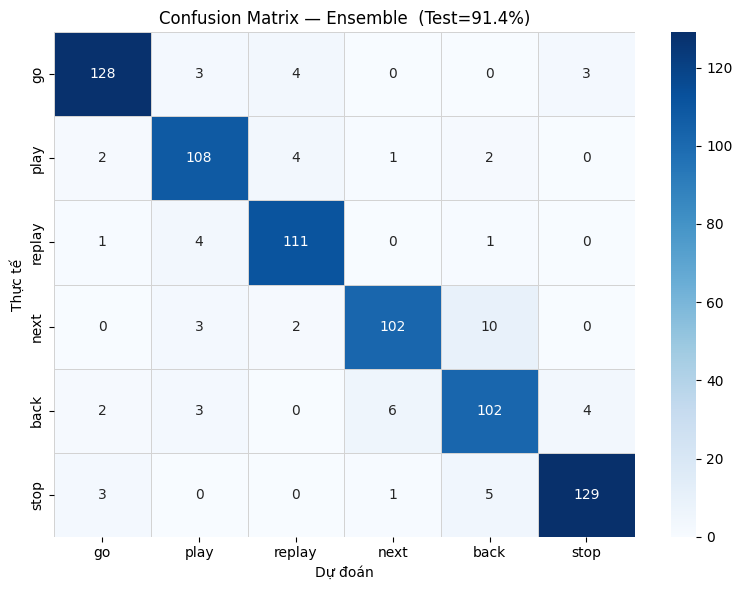

✅ Lưu → /content/drive/MyDrive/Cuoi_ki_AI/logs/confusion_matrix.png

❌ Top lỗi nhầm:
   'next' → 'back': 10 lần
   'back' → 'next': 6 lần
   'stop' → 'back': 5 lần
   'replay' → 'play': 4 lần
   'play' → 'replay': 4 lần


In [14]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns, matplotlib.pyplot as plt

scores = {
    'SVM':      (best_svm,  svm_grid.best_score_),
    'RF':       (rf_pipe,   rf_scores.mean()),
    'Ensemble': (ensemble,  ens_scores.mean()),
}
best_name  = max(scores, key=lambda k: scores[k][1])
best_model = scores[best_name][0]

print(f"🏆 Model tốt nhất: {best_name}\n")
print(f"  {'Model':<10}  {'CV':>7}  {'Test':>7}")
for name, (mdl, cv_sc) in scores.items():
    acc = accuracy_score(y_test_s, mdl.predict(X_test))
    print(f"  {name:<10}  {cv_sc*100:>6.2f}%  {acc*100:>6.2f}%")

y_pred_best = best_model.predict(X_test)
acc_best    = accuracy_score(y_test_s, y_pred_best)

print(f"\n{'='*50}")
print(f"Classification Report — {best_name}:\n")
print(classification_report(y_test_s, y_pred_best, target_names=LABELS))

# Confusion Matrix
cm = confusion_matrix(y_test_s, y_pred_best, labels=LABELS)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABELS, yticklabels=LABELS,
            linewidths=0.5, linecolor='lightgray')
plt.title(f'Confusion Matrix — {best_name}  (Test={acc_best*100:.1f}%)')
plt.ylabel('Thực tế'); plt.xlabel('Dự đoán')
plt.tight_layout()
cm_path = f'{LOG_DIR}/confusion_matrix.png'
plt.savefig(cm_path, dpi=150)
plt.show()
print(f"✅ Lưu → {cm_path}")

# Top lỗi
print("\n❌ Top lỗi nhầm:")
errors = [(cm[i][j], LABELS[i], LABELS[j])
          for i in range(len(LABELS)) for j in range(len(LABELS))
          if i != j and cm[i][j] > 0]
for cnt, t, p in sorted(errors, reverse=True)[:5]:
    print(f"   '{t}' → '{p}': {cnt} lần")

# Cell 15 — Lưu model vào Drive

In [15]:
import joblib, datetime

ts = datetime.datetime.now().strftime('%Y%m%d_%H%M')

model_package = {
    'model':           best_model,
    'label_encoder':   le,
    'labels':          LABELS,
    'sr':              SR,
    'duration':        DURATION,
    'n_mfcc':          N_MFCC,
    'best_model_name': best_name,
    'test_accuracy':   float(acc_best),
    'trained_at':      ts,
    'data_sources':    'mine(aug×4) + google_sc_v2(200/class) + tts_synthesis',
}

fixed_path = f'{MODEL_DIR}/speech_command_model.pkl'
stamp_path = f'{MODEL_DIR}/speech_model_{best_name}_{ts}.pkl'

joblib.dump(model_package, fixed_path)
joblib.dump(model_package, stamp_path)

print(f"✅ Model lưu lên Drive:")
print(f"   {fixed_path}   ← backend dùng file này")
print(f"   {stamp_path}")
print(f"\n   Model       : {best_name}")
print(f"   Test acc    : {acc_best*100:.2f}%")
print(f"   Feature dims: {X.shape[1]}")
print(f"   Data sources: mine(aug×4) + GSC_v2(200/lớp) + TTS")

✅ Model lưu lên Drive:
   /content/drive/MyDrive/Cuoi_ki_AI/models/speech_command_model.pkl   ← backend dùng file này
   /content/drive/MyDrive/Cuoi_ki_AI/models/speech_model_Ensemble_20260425_1519.pkl

   Model       : Ensemble
   Test acc    : 91.40%
   Feature dims: 248
   Data sources: mine(aug×4) + GSC_v2(200/lớp) + TTS


# Cell 16 — Test với folder test riêng

In [16]:
import librosa, numpy as np, os, joblib

pkg        = joblib.load(f'{MODEL_DIR}/speech_command_model.pkl')
best_model = pkg['model']
le         = pkg['label_encoder']

TEST_FOLDER = f'{BASE}/test'

def predict_file(fpath):
    y, sr   = librosa.load(fpath, sr=SR, mono=True)
    feat    = extract_features(y, sr).reshape(1, -1)
    pred    = best_model.predict(feat)[0]
    proba   = best_model.predict_proba(feat)[0]
    return pred, proba

if not os.path.exists(TEST_FOLDER):
    print(f"⚠️  Không tìm thấy {TEST_FOLDER}")
else:
    files = sorted([f for f in os.listdir(TEST_FOLDER)
                    if f.lower().endswith(('.m4a','.wav','.mp3'))])

    print("=" * 55)
    print(f"{'File':<20} {'Dự đoán':<10} {'Conf':>7}   Đúng?")
    print("=" * 55)

    correct = 0
    for fname in files:
        fpath      = os.path.join(TEST_FOLDER, fname)
        true_label = os.path.splitext(fname)[0].lower()
        pred, proba = predict_file(fpath)
        conf        = np.max(proba) * 100
        ok          = (pred == true_label)
        if ok: correct += 1
        print(f"{fname:<20} {pred:<10} {conf:>6.1f}%   {'✅' if ok else '❌'}")

    print("=" * 55)
    print(f"Accuracy: {correct}/{len(files)} = {correct/len(files)*100:.1f}%")

    print("\n📊 Top-3 chi tiết:\n")
    for fname in files:
        fpath       = os.path.join(TEST_FOLDER, fname)
        true_label  = os.path.splitext(fname)[0].lower()
        pred, proba = predict_file(fpath)
        top3        = np.argsort(proba)[::-1][:3]
        print(f"🎵 {fname}  ({'✅' if pred==true_label else '❌'})")
        for i in top3:
            lbl = le.inverse_transform([i])[0]
            bar = '█' * int(proba[i]*30)
            print(f"   {lbl:<8} {proba[i]*100:5.1f}%  {bar}{' ◀' if lbl==pred else ''}")
        print()

File                 Dự đoán       Conf   Đúng?


/tmp/ipykernel_5721/3038726015.py:10: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr   = librosa.load(fpath, sr=SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


back.m4a             next         53.0%   ❌


/tmp/ipykernel_5721/3038726015.py:10: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr   = librosa.load(fpath, sr=SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


go.m4a               go           90.2%   ✅


...

🎵 play.m4a  (✅)
   play      49.6%  ██████████████ ◀
   next      14.0%  ████
   replay    13.0%  ███



/tmp/ipykernel_5721/3038726015.py:10: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr   = librosa.load(fpath, sr=SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


🎵 replay.m4a  (✅)
   replay    75.4%  ██████████████████████ ◀
   play      12.7%  ███
   back       4.4%  █



/tmp/ipykernel_5721/3038726015.py:10: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr   = librosa.load(fpath, sr=SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


🎵 stop.m4a  (✅)
   stop      79.7%  ███████████████████████ ◀
   back       6.8%  ██
   next       5.9%  █

